In [1]:
import glob
from fashion_clip.fashion_clip import FashionCLIP
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json

/Users/edawg/Projects/other/fashionabler/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fclip = FashionCLIP('fashion-clip')

In [ ]:
with open('old/styles.csv', 'r') as f:
    styles = f.read().splitlines()

data = [line.split(',') for line in styles]
header = data[0]
data = data[1:]

to_save = {}
for path in glob.glob('old/imgs/segmented/*'):
    for row in data:
        if row[0] == path.split('/')[-1].split('.')[0]:
            to_save[path] = {header[i]: row[i] for i in range(len(header))}
            break

with open('old/metadata.json', 'w') as f:
    json.dump(to_save, f, indent=4)

# run scripts/encode_images.py now to encode the images

In [13]:
prompt = 'crazy goofy'
text_embedding = fclip.encode_text([prompt], batch_size=1)
text_embedding /= np.linalg.norm(
    text_embedding, ord=2, axis=-1, keepdims=True)

100%|██████████| 1/1 [00:00<00:00, 23.93it/s]


/var/folders/5n/gv9dwx994nl9lprt25l53_br0000gn/T/ipykernel_14668/2765544475.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  groups = df.groupby('articleType').apply(lambda x: x.sort_values('similarity', ascending=False).head(1)).reset_index(drop=True)


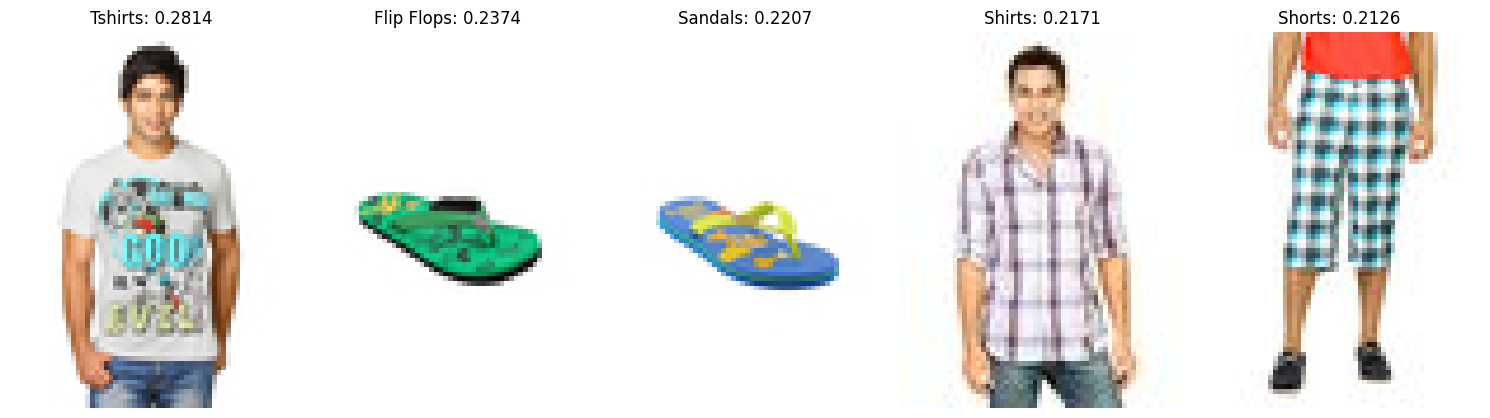

In [14]:
with open('old/metadata.json', 'r') as f:
        metadata = json.load(f)
df = pd.DataFrame(metadata).T
df['imagePath'] = df.index

# calculate similarity
df['similarity'] = df['embedding'].apply(
    lambda x: np.dot(text_embedding, np.array(x))[0])

# remove undesired items
df = df[df['masterCategory'].isin(['Footwear', 'Accessories', 'Apparel'])]  # only clothing
df = df[~df['gender'].isin(['Women', 'Girls'])]  # no mens clothing

# top item for each category
groups = df.groupby('articleType').apply(lambda x: x.sort_values('similarity', ascending=False).head(1)).reset_index(drop=True)
groups = groups.set_index('articleType').sort_values('similarity', ascending=False)

# plot top categories
items = 5
fig, axes = plt.subplots(1, items, figsize=(15, 5))
for ax, (category, row) in zip(axes, groups.iterrows()):
    img = row['imagePath']
    ax.imshow(plt.imread(img))
    ax.set_title(f'{category}: {row['similarity']:.4f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

### Compare images with similar embeddings for outfit creation

Index(['Tshirts', 'Flip Flops', 'Sandals', 'Shirts', 'Shorts', 'Sweaters',
       'Jeans', 'Sunglasses', 'Socks', 'Trousers', 'Sports Shoes',
       'Track Pants', 'Innerwear Vests', 'Jackets', 'Casual Shoes',
       'Sweatshirts', 'Boxers', 'Formal Shoes', 'Backpacks', 'Ties', 'Trunk',
       'Mufflers', 'Watches', 'Tracksuits', 'Briefs', 'Caps', 'Messenger Bag',
       'Hat', 'Lounge Shorts', 'Duffel Bag', 'Handbags', 'Accessory Gift Set',
       'Shoe Accessories', 'Wallets', 'Cufflinks', 'Laptop Bag', 'Headband',
       'Belts'],
      dtype='object', name='articleType')
Closest image to target


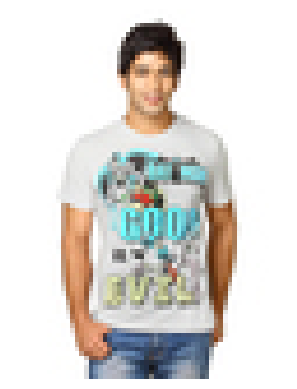

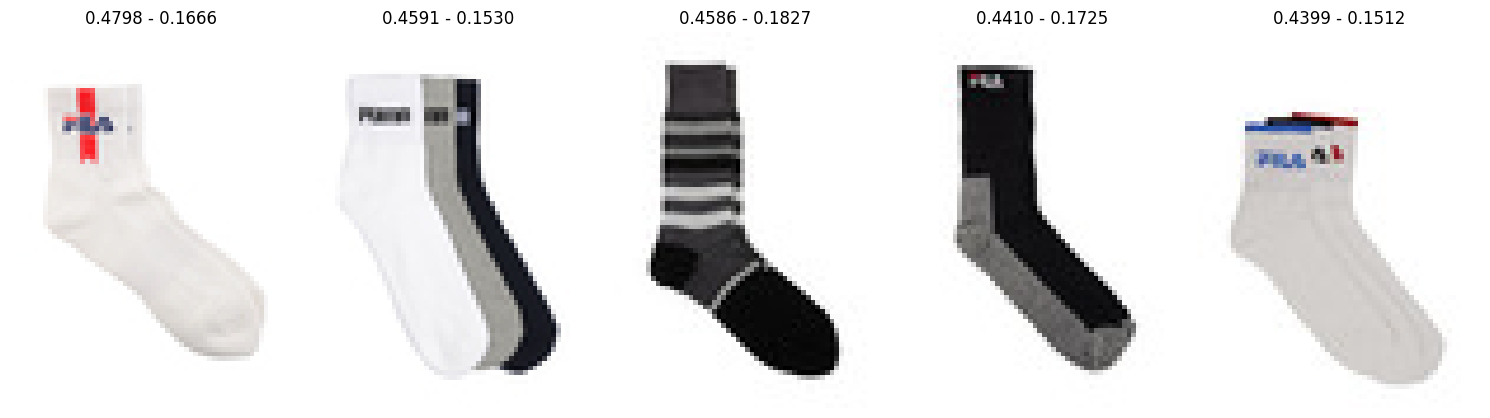

In [ ]:
print(groups.index.unique())

target_embedding = np.array(groups.iloc[0]['embedding']).reshape(1, -1)

df['similarity_to_target'] = df['embedding'].apply(lambda x: np.dot(target_embedding, x)[0])

closest_df = df.sort_values('similarity_to_target', ascending=False)
closest_images = closest_df[closest_df['articleType']=='Socks'].head(5)
plt.imshow(plt.imread(groups.iloc[0]['imagePath']))
plt.title("Target Image")
plt.axis('off')
plt.show()

print("")
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, (_, row) in zip(axes, closest_images.iterrows()):
    img = row['imagePath']
    ax.imshow(plt.imread(img))
    ax.set_title(f'{row["similarity_to_target"]:.4f} - {row["similarity"]:.4f}')
    ax.axis('off')
plt.tight_layout()


/var/folders/5n/gv9dwx994nl9lprt25l53_br0000gn/T/ipykernel_14621/2862176948.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category_top_k = df.groupby('category').apply(


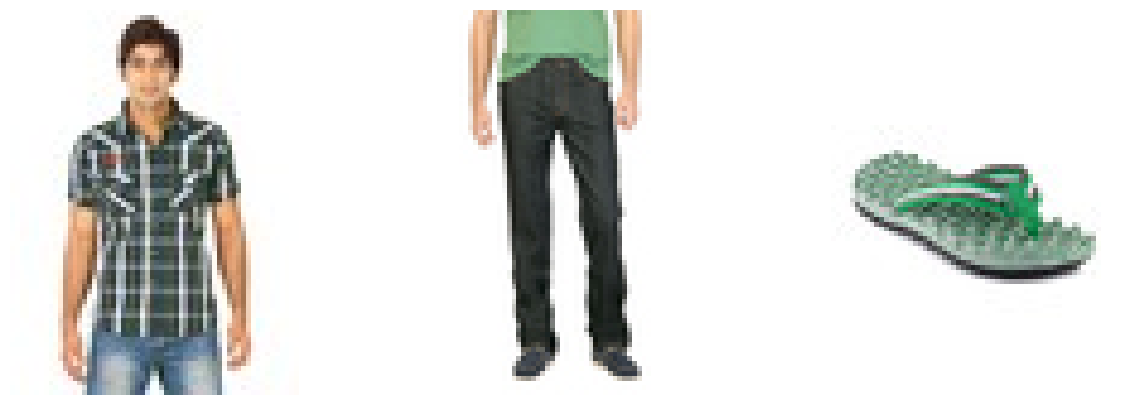

In [24]:
df = df[df['masterCategory'].isin(['Footwear', 'Accessories', 'Apparel'])]
df = df[~df['gender'].isin(['Women', 'Girls'])]

categories = {
    "tops": ['Tshirts', 'Shirts'],
    "bottoms": ['Trousers', 'Shorts', 'Jeans', 'Track Pants', 'Lounge Shorts'],
    "shoes": ['Casual Shoes', 'Sports Shoes', 'Sandals', 'Formal Shoes'],
    "socks": ['Socks'],
    "innerwear": ['Innerwear Vests', 'Briefs', 'Trunk', 'Boxers'],
    "outerwear": ['Jackets', 'Sweatshirts', 'Sweaters', 'Tracksuits'],
    "accessories": ['Watches', 'Sunglasses', 'Wallets',
                    'Belts', 'Shoe Accessories', 'Mufflers',
                    'Accessory Gift Set', 'Ties', 'Cufflinks'],
    "bags": ['Backpacks', 'Laptop Bag', 'Messenger Bag',
                'Duffel Bag', 'Handbags'],
    "headwear": ['Caps', 'Hats', 'Headband'],
}
base_categories = ['tops', 'bottoms', 'shoes']
aux_categories = ['socks', 'innerwear', 'outerwear', 'accessories', 'bags', 'headwear']

df['category'] = df.apply(
    lambda x: next(
        (k for k, v in categories.items() if x['articleType'] in v),
        None),
    axis=1)

alpha = 0.6
k = 5
category_top_k = df.groupby('category').apply(
    lambda x: x.sort_values(
        'similarity',
        ascending=False
    ).head(k)).reset_index(drop=True)

best_outfit = ([], 0)
for top_idx, top_row in category_top_k[category_top_k['category'] == 'tops'].iterrows():
    for bottom_idx, bottom_row in category_top_k[category_top_k['category'] == 'bottoms'].iterrows():
        cohesion = np.dot(top_row['embedding'], bottom_row['embedding'])
        for shoe_idx, shoe_row in category_top_k[category_top_k['category'] == 'shoes'].iterrows():
            cohesion += np.dot(top_row['embedding'], shoe_row['embedding'])
            cohesion += np.dot(bottom_row['embedding'], shoe_row['embedding'])
            cohesion /= 3
            similarity = (top_row['similarity'] + bottom_row['similarity'] + shoe_row['similarity'])/3
            score = alpha * similarity + (1-alpha) * cohesion
            if score > best_outfit[1]:
                best_outfit = ([top_idx, bottom_idx, shoe_idx], score)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, idx in zip(axes, best_outfit[0]):
    img = category_top_k.loc[idx]['imagePath']
    ax.imshow(plt.imread(img))
    ax.axis('off')

In [ ]:

def get_top_k_items(category, prompt_embedding, k=3):
    items = wardrobe[category]
    similarities = [cosine_similarity([item["embedding"]], [prompt_embedding])[0][0] for item in items]
    top_k_indices = np.argsort(similarities)[-k:][::-1]
    return [items[i] for i in top_k_indices]

# Assemble outfits
def assemble_outfit(prompt_embedding):
    tops = get_top_k_items("tops", prompt_embedding)
    bottoms = get_top_k_items("bottoms", prompt_embedding)
    shoes = get_top_k_items("shoes", prompt_embedding)
    
    # Combine items into outfits
    outfits = []
    for top in tops:
        for bottom in bottoms:
            for shoe in shoes:
                # Score outfit based on pairwise compatibility
                outfit_score = (
                    cosine_similarity([top["embedding"]], [bottom["embedding"]])[0][0] +
                    cosine_similarity([top["embedding"]], [shoe["embedding"]])[0][0] +
                    cosine_similarity([bottom["embedding"]], [shoe["embedding"]])[0][0]
                )
                outfits.append({
                    "top": top["name"],
                    "bottom": bottom["name"],
                    "shoe": shoe["name"],
                    "score": outfit_score,
                })
    
    # Rank outfits by score
    outfits.sort(key=lambda x: x["score"], reverse=True)
    return outfits[:5]  # Return top 5 outfits

# Example usage
outfits = assemble_outfit(prompt_embedding)
for outfit in outfits:
    print(outfit)